<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Stability002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-165385779.py:89: UserWarning: Glyph 120033 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL R}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


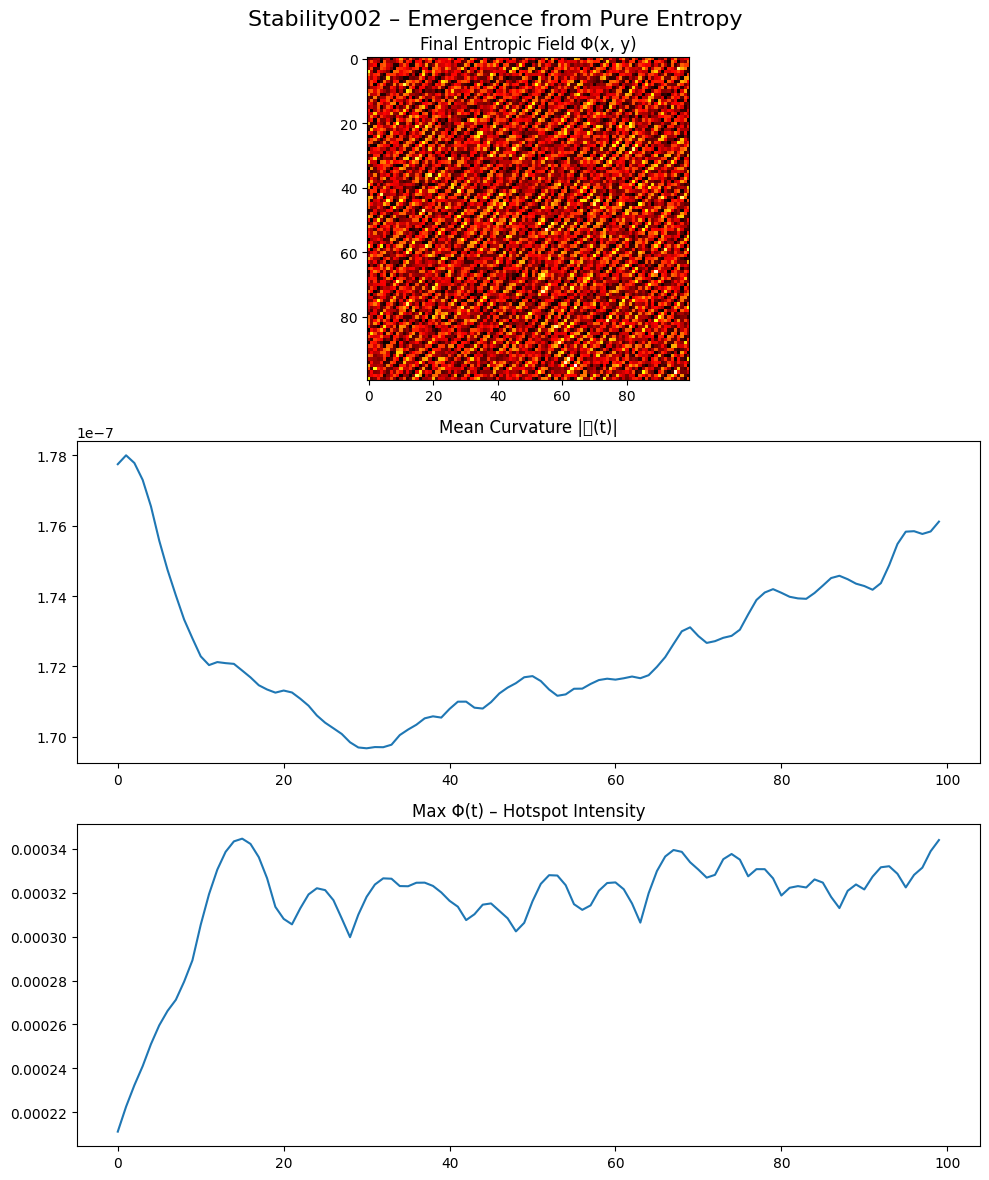

In [ ]:
# Stability002: First-Principle Emergence Test – HES-ATTRACT V2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
alpha = 0.1       # Entropic diffusion
beta = 0.01       # Self-reinforcement
gamma = 0.02      # Global feedback
delta = 0.02      # Curvature self-coupling
L = 100           # Lattice size
T_max = 100       # Timesteps
epsilon = 1e-10   # Numerical stability

# -----------------------------
# Initialize Pure Entropic Field
# -----------------------------
def initialize_noise_field(L):
    phi = np.random.rand(L, L)
    phi = np.maximum(phi, 0)
    phi /= np.sum(phi + epsilon)
    return phi

# -----------------------------
# Compute Entropy Field
# -----------------------------
def compute_entropy(phi):
    return -phi * np.log(phi + epsilon)

# -----------------------------
# Compute Ricci Scalar (Curvature)
# -----------------------------
def compute_curvature(S, L):
    laplacian_S = (
        -4 * S +
        np.roll(S, 1, axis=0) + np.roll(S, -1, axis=0) +
        np.roll(S, 1, axis=1) + np.roll(S, -1, axis=1)
    ) / (L ** 2)
    return laplacian_S

# -----------------------------
# Update Rule (HES-ATTRACT V2)
# -----------------------------
def update_field(phi, alpha, beta, gamma, delta, L):
    grad_phi_x = (np.roll(phi, -1, axis=0) - np.roll(phi, 1, axis=0)) / 2
    grad_phi_y = (np.roll(phi, -1, axis=1) - np.roll(phi, 1, axis=1)) / 2
    grad_phi = grad_phi_x + grad_phi_y

    phi_mean = np.mean(phi)
    S = compute_entropy(phi)
    R = compute_curvature(S, L)

    phi_new = phi - alpha * grad_phi + beta * phi + gamma * phi_mean * phi + delta * R
    phi_new = np.maximum(phi_new, 0)
    phi_new /= np.sum(phi_new + epsilon)
    return phi_new, R

# -----------------------------
# Run Simulation
# -----------------------------
phi = initialize_noise_field(L)
curvature_series = []
hotspot_series = []

for t in range(T_max):
    phi, R = update_field(phi, alpha, beta, gamma, delta, L)
    curvature_series.append(np.mean(np.abs(R)))
    hotspot_series.append(np.max(phi))

# -----------------------------
# Plot Results
# -----------------------------
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Final field snapshot
axs[0].imshow(phi, cmap='hot')
axs[0].set_title("Final Entropic Field Φ(x, y)")

# Curvature over time
axs[1].plot(curvature_series)
axs[1].set_title("Mean Curvature |𝓡(t)|")

# Hotspot intensity over time
axs[2].plot(hotspot_series)
axs[2].set_title("Max Φ(t) – Hotspot Intensity")

fig.suptitle("Stability002 – Emergence from Pure Entropy", fontsize=16)
plt.tight_layout()
plt.show()
